In [1]:
import os

os.chdir("..")

In [7]:
import sys
from pathlib import Path
from matplotlib import animation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Ensure src is on path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loader import load_all_data
from src.core.route_scheduler import RouteScheduler

# Load data and chromosome
airport_codes, route_durations, demand_list = load_all_data("data")
airports_df = pd.read_csv("data/airports.csv")
code_to_latlon = {row.code: (float(row.lat), float(row.lon)) for _, row in airports_df.iterrows()}
best_chromosome = pd.read_pickle("results/best_chromosome.pkl")

# Build flight events with timings
events = []  # each: dict(origin, dest, dep, arr)
for aid, route in enumerate(best_chromosome.get_routes()):
    airports = route.get_airports()
    if len(airports) < 2:
        continue
    schedule = RouteScheduler.compute_schedule(route, route_durations)
    # schedule[i] = (dep_time, dest, arr_time) for leg airports[i] -> airports[i+1]
    for i, (dep_time, dest, arr_time) in enumerate(schedule):
        origin = airports[i]
        events.append({"aid": aid, "origin": origin, "dest": dest, "dep": dep_time, "arr": arr_time})

if not events:
    print("No flight events found. Ensure best_chromosome.pkl is from a completed run.")
else:
    # Positions using latitude/longitude scaled to [-1, 1]
    lats = [code_to_latlon.get(c, (0, 0))[0] for c in airport_codes]
    lons = [code_to_latlon.get(c, (0, 0))[1] for c in airport_codes]
    lat_min, lat_max = min(lats), max(lats)
    lon_min, lon_max = min(lons), max(lons)
    def norm(val, vmin, vmax):
        return 0.0 if vmax == vmin else (val - vmin) / (vmax - vmin)
    positions = {}
    for code in airport_codes:
        lat, lon = code_to_latlon.get(code, (0, 0))
        x = (norm(lon, lon_min, lon_max) - 0.5) * 2
        y = (norm(lat, lat_min, lat_max) - 0.5) * 2
        positions[code] = (x, y)

    # Time grid (minutes from earliest dep to latest arr)
    min_time = min(e["dep"] for e in events)
    max_time = max(e["arr"] for e in events)
    step = 5  # minutes per frame
    frames = list(range(min_time, max_time + step, step))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal")
    ax.axis("off")

    # Draw airports
    for code, (x, y) in positions.items():
        ax.plot(x, y, "ko", markersize=8)
        ax.text(x, y + 0.05, code, ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Static edges (all possible legs in routes)
    for e in events:
        x1, y1 = positions[e["origin"]]
        x2, y2 = positions[e["dest"]]
        ax.plot([x1, x2], [y1, y2], color="lightgray", linewidth=0.5, alpha=0.4)

    # Scatter for moving aircraft
    scatter = ax.scatter([], [], s=30, c="blue", alpha=0.8)
    title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center", va="bottom", fontsize=10)

    def update(frame_time):
        active_x, active_y = [], []
        for e in events:
            if e["dep"] <= frame_time < e["arr"]:
                t_frac = (frame_time - e["dep"]) / (e["arr"] - e["dep"])
                x1, y1 = positions[e["origin"]]
                x2, y2 = positions[e["dest"]]
                active_x.append(x1 + (x2 - x1) * t_frac)
                active_y.append(y1 + (y2 - y1) * t_frac)
        scatter.set_offsets(np.column_stack([active_x, active_y]) if active_x else np.empty((0, 2)))
        title.set_text(f"Time: {frame_time//60:02.0f}:{frame_time%60:02.0f} | Active flights: {len(active_x)}")
        return scatter, title

    anim = animation.FuncAnimation(fig, update, frames=frames, interval=100, blit=False)

    gif_path = Path("results") / "flight_animation.gif"
    anim.save(gif_path, writer="pillow", fps=10)
    plt.close(fig)
    print(f"Saved animation to {gif_path}")

gif_path

Saved animation to results/flight_animation.gif


PosixPath('results/flight_animation.gif')

# Genetic Algorithm Results

Quick analysis of the generated pickles in `results/`. Run cells top-to-bottom after a GA run.

In [20]:
import os
import math
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')

stats = pd.read_pickle("results/stats.pkl")

allocations = stats.get("allocations", [])
unmet_demands = stats.get("unmet_demands", [])
print(f"Loaded stats with {len(allocations)} allocations and {len(unmet_demands)} unmet demands")

alloc_df = pd.DataFrame(
    allocations,
    columns=["origin", "dest", "passengers", "aircraft_id", "stops"],
)
alloc_df.head()

Loaded stats with 622 allocations and 0 unmet demands


,origin,dest,passengers,aircraft_id,stops
0,FO,SA,180,27,0
1,FO,SA,180,63,0
2,FO,SA,40,98,1
3,FO,CI,180,121,0
4,FO,CI,20,137,0


In [21]:
# Summary metrics
served = alloc_df["passengers"].sum()
unserved = stats.get("unserved_passengers", 0)
total_demand = served + unserved
service_rate = served / total_demand * 100 if total_demand else 0

print(
    f"Served: {served:,}\n"
    f"Unserved: {unserved:,}\n"
    f"Total flights: {stats.get('total_flights', 'N/A')}\n"
    f"Total stops (weighted): {stats.get('total_stops', 'N/A')}\n"
    f"Fitness: {stats.get('fitness_score', 'N/A')}\n"
    f"Service rate: {service_rate:.2f}%"
)

Served: 94,800
Unserved: 0
Total flights: 181
Total stops (weighted): 360
Fitness: 720.0
Service rate: 100.00%


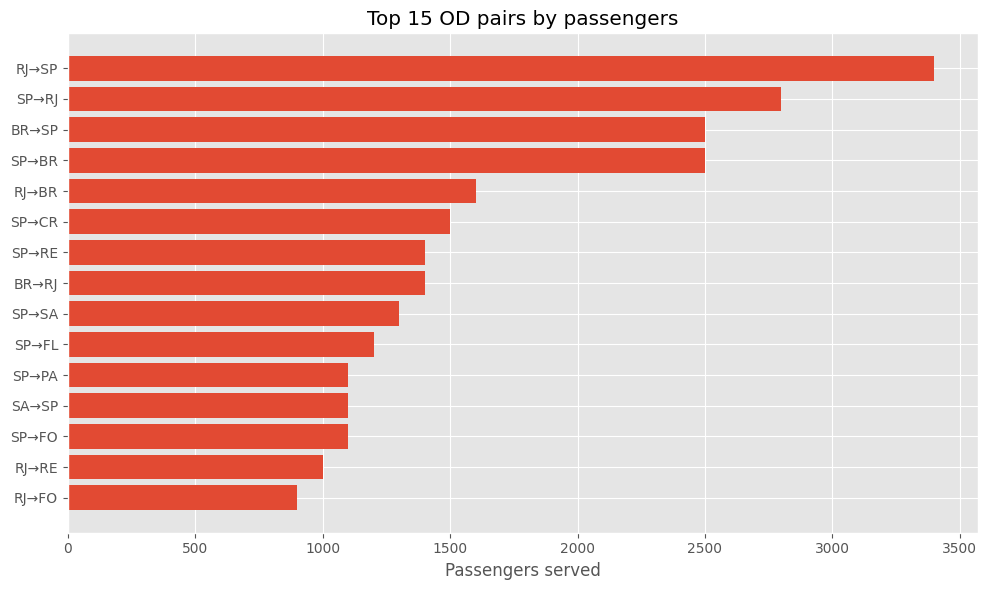

,origin,dest,passengers
0,RJ,SP,3400
1,SP,RJ,2800
2,BR,SP,2500
3,SP,BR,2500
4,RJ,BR,1600
5,SP,CR,1500
6,SP,RE,1400
7,BR,RJ,1400
8,SP,SA,1300
9,SP,FL,1200


In [6]:
# Top origin-destination pairs by passengers served
top_od = (
    alloc_df.groupby(["origin", "dest"])["passengers"].sum()
    .sort_values(ascending=False)
    .reset_index()
)
top_n = 15
if top_od.empty:
    print("No allocations available.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        [f"{o}→{d}" for o, d in zip(top_od.origin.head(top_n), top_od.dest.head(top_n))],
        top_od.passengers.head(top_n),
    )
    ax.invert_yaxis()
    ax.set_title(f"Top {top_n} OD pairs by passengers")
    ax.set_xlabel("Passengers served")
    plt.tight_layout()
    plt.show()

top_od.head(top_n)

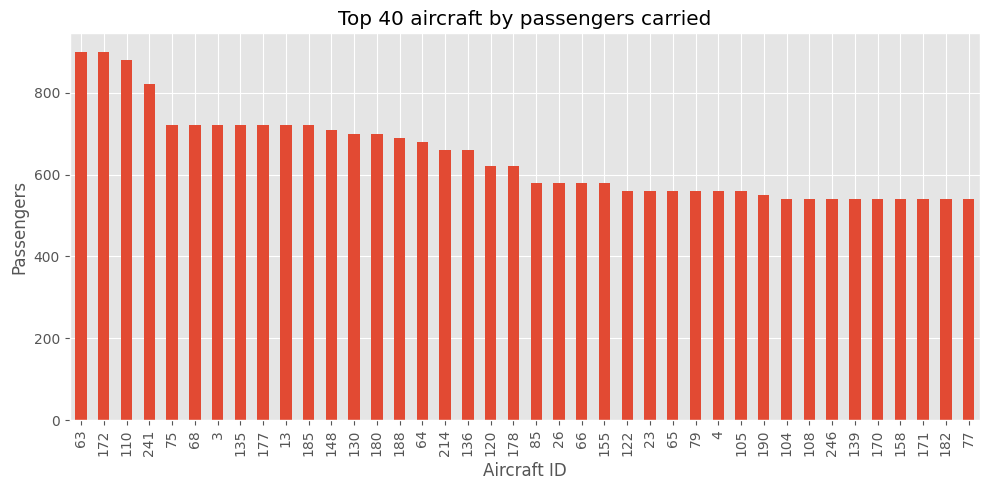

Utilization summary (all aircraft):


count    247.000000
mean     383.805668
std      174.705591
min       20.000000
25%      240.000000
50%      360.000000
75%      540.000000
max      900.000000
Name: passengers, dtype: float64

In [7]:
# Aircraft utilization
aircraft_usage = (
    alloc_df.groupby("aircraft_id")["passengers"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
aircraft_usage.head(40).plot(kind="bar", ax=ax)
ax.set_title("Top 40 aircraft by passengers carried")
ax.set_xlabel("Aircraft ID")
ax.set_ylabel("Passengers")
plt.tight_layout()
plt.show()

print("Utilization summary (all aircraft):")
display(aircraft_usage.describe())

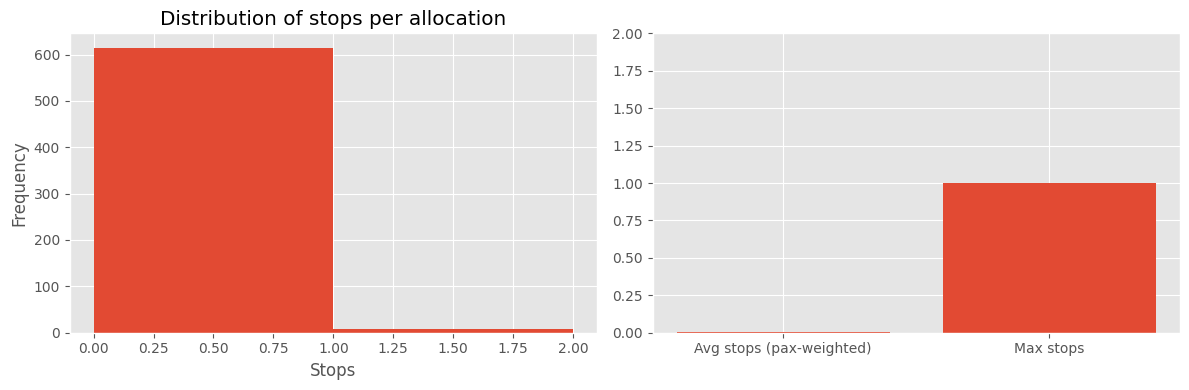

Passenger-weighted average stops: 0.00


In [8]:
# Stops distribution
if alloc_df.empty:
    print("No allocations available for stops analysis.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    alloc_df["stops"].plot(kind="hist", bins=range(0, alloc_df["stops"].max() + 2), ax=axes[0])
    axes[0].set_title("Distribution of stops per allocation")
    axes[0].set_xlabel("Stops")

    avg_stops_weighted = (
        (alloc_df["stops"] * alloc_df["passengers"]).sum() / alloc_df["passengers"].sum()
        if not alloc_df.empty else 0
    )
    axes[1].bar(["Avg stops (pax-weighted)", "Max stops"], [avg_stops_weighted, alloc_df["stops"].max()])
    axes[1].set_ylim(0, max(1, alloc_df["stops"].max() + 1))
    plt.tight_layout()
    plt.show()

    print(f"Passenger-weighted average stops: {avg_stops_weighted:.2f}")

In [9]:
# Unmet demand overview (if any)
if unmet_demands:
    unmet_df = pd.DataFrame(unmet_demands, columns=["origin", "dest", "passengers"])
    display(unmet_df.sort_values("passengers", ascending=False).head(20))
else:
    print("No unmet demands in this run.")

No unmet demands in this run.


In [12]:
alloc_df[alloc_df.aircraft_id == 63]

,origin,dest,passengers,aircraft_id,stops
1,FO,SA,180,63,0
455,FL,PA,180,63,0
535,SA,RE,180,63,0
555,PA,SA,180,63,0
585,SA,FO,180,63,0


In [13]:
pd.read_pickle("../results/best_chromosome.pkl")

ModuleNotFoundError: No module named 'src'